This notebook was used to expose ourselves into sentiment analysis using pre-trained model from NLTK and TextBlob. This is to familiarize ourselves with sentiment analysis understanding before diving into using large-scale pre-trained model in hugging face.

# Import libraries and load data

In [134]:
import pandas as pd
import joblib

In [135]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [136]:
df = joblib.load('./drive/My Drive/BT4222/cleaned_data.pkl')

In [137]:
from sklearn.utils import shuffle
df = shuffle(df)

In [138]:
len(df)

200000

In [139]:
df.head(5)

,votes,user_id,review_id,stars_x,date,text,type_x,business_id,label_x,text_length,...,neighborhoods,longitude,state,stars_y,latitude,attributes,type_y,label_y,review_splitted,cleaned
565147,"{'funny': 0, 'useful': 2, 'cool': 0}",YDVFMRXvEupasDfjf3cx4g,4JWTAIIVa9LEJQ9HpYwkrw,3,2013-07-26,"Boasting some of the best margaritas in town, Lindo Michoacan caters to the locals of Las Vegas and Summerlin. Spacious seating and attentive servers allows this friendly Catina to accommodate both large and small groups well. There is daily live music although it is not the authentic sound I would expect at a Mexican restaurant. This place is good, and I would go back, but it will not know your socks off. You will leave satisfied but not blown away.",review,OWyFd29_AWly7vmR6hOKEQ,0,80,...,[Spring Valley],-115.312508,NV,3.5,36.115454,"{'Take-out': True, 'Wi-Fi': 'free', 'Good For': {'dessert': False, 'latenight': False, 'lunch': False, 'dinner': True, 'breakfast': False, 'brunch': False}, 'Caters': True, 'Noise Level': 'average', 'Takes Reservations': True, 'Ambience': {'romantic': False, 'intimate': False, 'touristy': False, 'hipster': False, 'divey': False, 'classy': False, 'trendy': False, 'upscale': False, 'casual': True}, 'Has TV': True, 'Delivery': False, 'Dogs Allowed': False, 'Parking': {'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}, 'Wheelchair Accessible': True, 'Outdoor Seating': True, 'Attire': 'casual', 'Alcohol': 'full_bar', 'Waiter Service': True, 'Accepts Credit Cards': True, 'Good for Kids': True, 'Good For Groups': True, 'Price Range': 2}",business,1.0,"[Boasting some of the best margaritas in town, Lindo Michoacan caters to the locals of Las Vegas and Summerlin., Spacious seating and attentive servers allows this friendly Catina to accommodate both large and small groups well., There is daily live music although it is not the authentic sound I would expect at a Mexican restaurant., This place is good, and I would go back, but it will not know your socks off., You will leave satisfied but not blown away.]","[boasting best margarita town lindo michoacan caters local la vega summerlin, spacious seat attentive server allows friendly catina accommodate large small group well, daily live music although not authentic sound would expect mexican restaurant, place good would go back not know sock, leave satisfied not blown away]"
1071467,"{'funny': 0, 'useful': 2, 'cool': 0}",mBqvx2BAoAywrwMZr_wWtQ,WCNYkFUtBHA0TcToH13DxA,2,2014-04-11,"Went here for lunch. Was a little confused where the entrance was. The entire restaurant is open so you can see out onto the street and people walking or driving by can see in. It's sort of roped off and you walk around the side of the building to get in. I like the fact that you can see the cooks preparing the food but I hated the dinning area. It is very small and they cram as many tables as possible into a tiny area. It was 2 of us and they sat us at a 2 person table next to a table of four. The tables were so close together we might as well have been siting with them. If I stuck my elbow out it would have touched the person sitting at the next table. To me that is ridiculous. Thankfully they were wrapping up so we asked to be moved over after they left. Now the menu, first thing I noticed was that the food is EXTREMELY over priced and there are no lunch specials. I specifically asked the waiter did the meals come with sides and he said beans and rice. The fish taco...",review,atzOrsnL_2pL6OttGbgUeA,0,348,...,[Downtown],-115.139550,NV,3.5,36.168740,"{'Take-out': True, 'Wi-Fi': 'no', 'Good For': {'dessert': False, 'latenight': False, 'lunch': False, 'dinner': True, 'brunch': False, 'breakfast': False}, 'Caters': True, 'Noise Level': 'average', 'Takes Reservations': True, 'Delivery': False, 'Ambience': {'romantic': False, 'intimate': False, 'classy': False, 'hipster': False, 'divey': False, 'touristy': False, 'trendy': True, 'upscale': False, 'casual': False}, 'Parki

# Exploratory: Distribution of Star Ratings 

**Use the result of this plot to include in final report:**

We see that each review in each star rating can have different polarity score. It means a low start rating does not directly imply negative comments, it might have some positive comments in between. This is where we want to leverage to gain insight by parsing the reviews topic by topic. 

In [140]:
df["stars_x"].value_counts()

4    54110
3    45941
5    45890
2    30171
1    23888
Name: stars_x, dtype: int64

In [141]:
df_positive = df[df["stars_x"]>=4]
df_negative = df[df["stars_x"]<4]

In [142]:
df = pd.concat([df_positive[:10000], df_negative[:10000]])

In [143]:
len(df)

20000

In [144]:
df["stars_x"].value_counts()

4    5425
5    4575
3    4544
2    3034
1    2422
Name: stars_x, dtype: int64

In [145]:
from textblob import TextBlob

def is_positive_blob(sentence):
  return TextBlob(sentence).polarity

In [146]:
df["Polarity"] = 0
df["Polarity"] = df["text"].apply(lambda x: TextBlob(x).sentiment.polarity) # Polarity score in review level

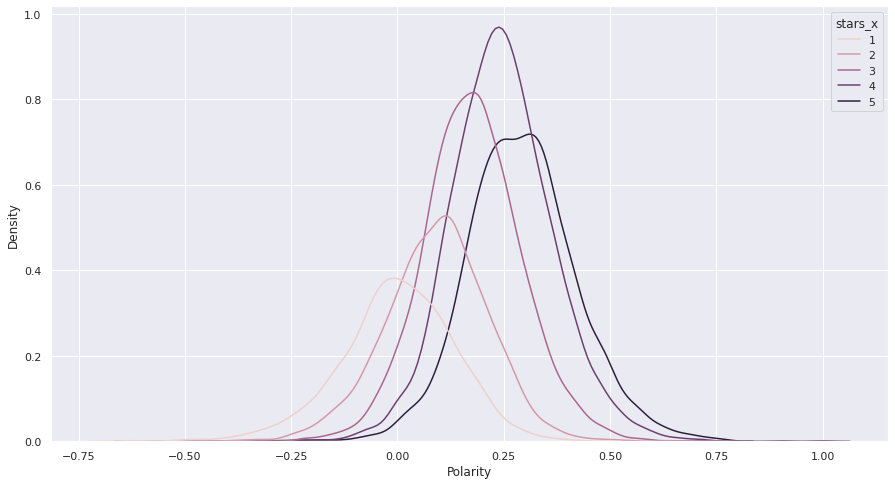

In [147]:
import seaborn as sns
sns.set(rc = {'figure.figsize':(15,8)})
sns.color_palette("tab10")
sns.kdeplot(data=df, x="Polarity", hue='stars_x')

# 1. Sentiment Analysis with NLTK



In [148]:
import nltk
nltk.download('punkt')
nltk.download('vader_lexicon') # vader is pre_trained especially for short sentence, social media sentiments

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

## Sentiment Analysis 

In [149]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
sia.polarity_scores("Wow, NLTK is so powerful") 
# Notice that polarity score will return "neg", "neu", "pos" which will sum up to 1
# We will use compound score instead, which is normalized sum of "neg", "neu", "pos" and range from -1 (most neg) to +1 (most pos)

{'compound': 0.8134, 'neg': 0.0, 'neu': 0.288, 'pos': 0.712}

In [150]:
def is_positive(sentence):
  # Means positive sentiment if compound score greater than 0 (can tweak this threshold)
  return sia.polarity_scores(sentence)["compound"] > 0 

In [151]:
df_review = pd.DataFrame()
df_review["Review"] = df["cleaned"][:1000] # Slice 1000 to speed up experiment
df_review["Sentiment"] = 0

positive_reviews = []
negative_reviews = []

positive_reviews_bigram = []
negative_reviews_bigram = []

positive_reviews_tfidf = []
negative_reviews_tfidf = []

def create_polarity_score(lst):
  result = []
  for sent in lst: # Find polarity score in sentence level
    if (is_positive(sent) and sent):
      result.append("Positive")
      positive_reviews_tfidf.append(sent)
      positive_reviews.extend(nltk.word_tokenize(sent))
      positive_reviews_bigram.extend(nltk.bigrams(nltk.word_tokenize(sent)))
    elif (sent):
      result.append("Negative")
      negative_reviews_tfidf.append(sent)
      negative_reviews.extend(nltk.word_tokenize(sent))
      negative_reviews_bigram.extend(nltk.bigrams(nltk.word_tokenize(sent)))
    else:
      result.append([])
  return result

df_review["Sentiment"] = df_review["Review"].apply(lambda x: create_polarity_score(x))

In [152]:
df_review.head(5)

,Review,Sentiment
47098,"[one favorite chinese restaurant arizona, food always good good size portion, love crap puff fry dumpling often order meal, general chicken great ask mild desire well chicken egg foo young, soup, hot sour not feel well allergy bugging order, food part consistent occasion really depends cook work not food come little different still good, service varies time time depend work busy, however price amount food get still worth, not pf chang yuppie type chinese food traditional chinese hole wall type place, eat year still enjoy, come expect pf chang disappointed come expect nice atmosphere good food decent price, place]","[Positive, Positive, Positive, Positive, Negative, Negative, Positive, Negative, Positive, Negative, Positive, Positive, Negative]"
1080415,"[today la vega nasty rainy, friend want grab lunch heard zupas really great soup, decide give try, arrive around place packed, usually good sign place good, could nt believe price, affordable, sand soup combo, order thai chicken sand wisconsin cauliflower soup, amaze, also order creme brûlée, also delicious, amaze service speed employee, not one seem irritated work, overall left happy full eager try]","[Negative, Positive, Negative, Negative, Positive, Negative, Negative, Negative, Negative, Positive, Negative, Positive, Positive, Positive, Positive]"
338876,"[finally buffet quantity quality, course still buffet nt come expect din experience romantic dinner two, buffet wynn la vega buffet experience buffet key word, come dinner left hour later, sure waitress thought pig, know felt like pig nt really care love food much, freshprepared food like pasta counter salad station custom crepe mound crab leg shrimp lamb prime rib game hen try get table welllit courtyard, nicer atmosphere, gelato candy apple profiterole chocolatecovered marshmallow cheese charcuterie dim sum dumpling soso asian dish, may sound like every buffet also nt, little thing nicer, food well, buffet well]","[Negative, Positive, Negative, Negative, Positive, Positive, Positive, Positive, Positive, Positive, Positive, Positive, Positive]"
8836,"[macapline blast past like eat lunch walk door back, worry bring part past huge selection vintage retro find, nt go expect quickness flexibility chain restaurant expect good time welcome atmosphere great dessert]","[Positive, Negative, Positive]"
776259,"[place probably close star rating without star, like raw organic natural food great mix food choice sort flavor delicious smoothy tea coffee sundry treat, oh nt forget make work behind counter ask oz wheat grass shot, love em, yes price not cheap well make food honest goodness good ingredient not come cheap, eat cheap fast food restaurant know well happen paltry day thanks mr spurlock, want eat healthy enjoy tasty meal process give pomegranate cafe two thumb, come give shot, course meant wheat grass shot, ]","[Negative, Positive, Negative, Positive, Positive, Positive, Positive, Negative, Negative, []]"


## Exploratory

In [153]:
df_check = df["stars_x"][:1000]
df_check["index"] = df_check.index
df_review["index"] = df_review.index
df_review_star = df_review.join(df_check, on="index")
df_review_star.drop("index", inplace=True, axis=1)

In [154]:
df_review_star

,Review,Sentiment,stars_x
47098,"[one favorite chinese restaurant arizona, food always good good size portion, love crap puff fry dumpling often order meal, general chicken great ask mild desire well chicken egg foo young, soup, hot sour not feel well allergy bugging order, food part consistent occasion really depends cook work not food come little different still good, service varies time time depend work busy, however price amount food get still worth, not pf chang yuppie type chinese food traditional chinese hole wall type place, eat year still enjoy, come expect pf chang disappointed come expect nice atmosphere good food decent price, place]","[Positive, Positive, Positive, Positive, Negative, Negative, Positive, Negative, Positive, Negative, Positive, Positive, Negative]",4
1080415,"[today la vega nasty rainy, friend want grab lunch heard zupas really great soup, decide give try, arrive around place packed, usually good sign place good, could nt believe price, affordable, sand soup combo, order thai chicken sand wisconsin cauliflower soup, amaze, also order creme brûlée, also delicious, amaze service speed employee, not one seem irritated work, overall left happy full eager try]","[Negative, Positive, Negative, Negative, Positive, Negative, Negative, Negative, Negative, Positive, Negative, Positive, Positive, Positive, Positive]",5
338876,"[finally buffet quantity quality, course still buffet nt come expect din experience romantic dinner two, buffet wynn la vega buffet experience buffet key word, come dinner left hour later, sure waitress thought pig, know felt like pig nt really care love food much, freshprepared food like pasta counter salad station custom crepe mound crab leg shrimp lamb prime rib game hen try get table welllit courtyard, nicer atmosphere, gelato candy apple profiterole chocolatecovered marshmallow cheese charcuterie dim sum dumpling soso asian dish, may sound like every buffet also nt, little thing nicer, food well, buffet well]","[Negative, Positive, Negative, Negative, Positive, Positive, Positive, Positive, Positive, Positive, Positive, Positive, Positive]",5
8836,"[macapline blast past like eat lunch walk door back, worry bring part past huge selection vintage retro find, nt go expect quickness flexibility chain restaurant expect good time welcome atmosphere great dessert]","[Positive, Negative, Positive]",4
776259,"[place probably close star rating without star, like raw organic natural food great mix food choice sort flavor delicious smoothy tea coffee sundry treat, oh nt forget make work behind counter ask oz wheat grass shot, love em, yes price not cheap well make food honest goodness good ingredient not come cheap, eat cheap fast food restaurant know well happen paltry day thanks mr spurlock, want eat healthy enjoy tasty meal process give pomegranate cafe two thumb, come give shot, course meant wheat grass shot, ]","[Negative, Positive, Negative, Positive, Positive, Positive, Positive, Negative, Negative, []]",4
...,...,...,...
292013,"[look nice birthday lunch sister nt good review yelp suitable year old, wellrated restaurant way budget la vega little fancy bring kid, luckily found mon ami gabi, everyone meal tasty, mushroom soup butter lettuce goat cheese apple salad seafood crepe, pea seafood crepe nice sweet fresh, kid mac cheese come thinly slice apple skinny green bean, delicious, found pick plate quite often, bottom line meal reasonable price especially compare restaurant area, waitress nice helpful suggest seafood crepe, restaurant nt fancy bring kid would frown upon, great place]","[Positive, Negative, Positive, Negative, Negative, Positive, Negative, Positive, Negative, Negative, Positive, Negative, Positive]",5
344426,"[stop last minute, manage get table quickly busy night, best get reservation want go, pricing well, food wonderful, everything order include dessert least rating, service excellent, friendly right amount attention without hover, view strip wynn nice taste la vega, ro

In [155]:
def isPositiveRating(x):
  if (x >= 4):
    return "Positive"
  return "Negative"

df_review_star["Rating"] = df_review_star["stars_x"].apply(lambda x: isPositiveRating(x))

In [156]:
def isPositiveRatingWithNegativeComment(lst):
  for x in lst:
    if (x=="Negative"):
      return 1
  return 0

df_positive = df_review_star[df_review_star["Rating"]=="Positive"]
df_positive["Got Negative Reviews"] = df_positive["Sentiment"].apply(lambda x: isPositiveRatingWithNegativeComment(x))
tot = df_positive["Got Negative Reviews"].sum()
print(str(tot) + " out of " + str(len(df_positive)) + " positive star ratings have negative reviews")
#942 out of 1000 positive star ratings contain negative comments too

947 out of 1000 positive star ratings have negative reviews


In [157]:
df["stars_x"][:1000].value_counts() # Our trial run star distribution

4    541
5    459
Name: stars_x, dtype: int64

## Selecting positive/negative features

### Using count method

In [158]:
# Will be working with positive_reviews and negative_reviews separately

positive_fd = nltk.FreqDist(positive_reviews)
negative_fd = nltk.FreqDist(negative_reviews)

common_set = set(positive_fd).intersection(negative_fd) # Remove common set

for word in common_set:
    del positive_fd[word]
    del negative_fd[word]

In [159]:
top_20_positive = {word for word, count in positive_fd.most_common(20)}
top_20_positive

{'beautiful',
 'clean',
 'comfortable',
 'compliment',
 'dumpling',
 'glad',
 'goodness',
 'healthy',
 'interest',
 'lol',
 'pleasant',
 'satisfy',
 'save',
 'scoop',
 'solid',
 'surprise',
 'thanks',
 'treat',
 'value',
 'wow'}

In [160]:
top_20_negative = {word for word, count in negative_fd.most_common(20)}
top_20_negative

{'bomb',
 'bus',
 'cosmo',
 'ding',
 'hallway',
 'kill',
 'mandalay',
 'nasty',
 'nom',
 'odd',
 'ostrich',
 'poor',
 'push',
 'radar',
 'ran',
 'ridiculous',
 'rough',
 'stingy',
 'stupid',
 'traffic'}

In [161]:
positive_fd_bi = nltk.FreqDist(positive_reviews_bigram)
negative_fd_bi = nltk.FreqDist(negative_reviews_bigram)

common_set = set(positive_fd_bi).intersection(negative_fd_bi) # Remove common set

for word in common_set:
    del positive_fd_bi[word]
    del negative_fd_bi[word]

In [162]:
top_20_positive_bi = {word for word, count in positive_fd_bi.most_common(20)}
top_20_positive_bi

{('always', 'good'),
 ('definitely', 'back'),
 ('definitely', 'come'),
 ('definitely', 'worth'),
 ('even', 'well'),
 ('food', 'great'),
 ('good', 'food'),
 ('great', 'service'),
 ('happy', 'hour'),
 ('highly', 'recommend'),
 ('one', 'best'),
 ('place', 'great'),
 ('pretty', 'good'),
 ('really', 'enjoy'),
 ('really', 'like'),
 ('really', 'nice'),
 ('recommend', 'place'),
 ('service', 'excellent'),
 ('service', 'good'),
 ('staff', 'friendly')}

In [163]:
top_20_negative_bi = {word for word, count in negative_fd_bi.most_common(20)}
top_20_negative_bi

{('bathroom', 'monitor'),
 ('bbq', 'place'),
 ('big', 'deal'),
 ('big', 'problem'),
 ('decide', 'stop'),
 ('get', 'pay'),
 ('go', 'last'),
 ('gold', 'coast'),
 ('grill', 'onion'),
 ('negative', 'review'),
 ('nom', 'nom'),
 ('nothing', 'else'),
 ('one', 'point'),
 ('order', 'burger'),
 ('people', 'complain'),
 ('serve', 'breakfast'),
 ('shrimp', 'taco'),
 ('stop', 'lunch'),
 ('take', 'look'),
 ('two', 'word')}

### Using TF-IDF

In [164]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [165]:
corpus = []
for lst in df_review["Review"]:
  if (len(lst) > 0):
    corpus.extend(lst)
print(len(corpus))

12420


In [166]:
vect = TfidfVectorizer()
tfidf = vect.fit_transform(corpus)

In [167]:
vect.get_feature_names_out()

array(['aa', 'aabs', 'abandon', ..., 'zum', 'zupas', 'zwischen'],
      dtype=object)

In [168]:
# Working with positive and negative reviews separately

pos_vect = TfidfVectorizer()
pos_tfidf = pos_vect.fit_transform(positive_reviews_tfidf)

neg_vect = TfidfVectorizer()
neg_tfidf = neg_vect.fit_transform(negative_reviews_tfidf)

df_tfidf = pd.DataFrame(pos_tfidf[0].T.todense(), index=pos_vect.get_feature_names(), columns=["TF-IDF Positive"])
df_tfidf = df_tfidf.sort_values('TF-IDF Positive', ascending=False)
print (df_tfidf.head(10))

df_tfidf2 = pd.DataFrame(neg_tfidf[0].T.todense(), index=neg_vect.get_feature_names(), columns=["TF-IDF Negative"])
df_tfidf2 = df_tfidf2.sort_values('TF-IDF Negative', ascending=False)
print (df_tfidf2.head(10))

            TF-IDF Positive
arizona            0.588577
chinese            0.517379
favorite           0.380684
restaurant         0.355073
one                0.338968
pls                0.000000
plethora           0.000000
plenty             0.000000
plentiful          0.000000
plebian            0.000000
          TF-IDF Negative
soup                  1.0
aabs                  0.0
plasma                0.0
plantain              0.0
plant                 0.0
planning              0.0
plank                 0.0
planet                0.0
plane                 0.0
plan                  0.0


/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)
/usr/local/lib/python3.7/dist-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function get_feature_names is deprecated; get_feature_names is deprecated in 1.0 and will be removed in 1.2. Please use get_feature_names_out instead.
  warnings.warn(msg, category=FutureWarning)


#2. Text Blob

In [169]:
from textblob import TextBlob

In [170]:
def is_positive_blob(sentence):
  return TextBlob(sentence).polarity

In [171]:
df_review_blob = pd.DataFrame()
df_review_blob["Review"] = df["cleaned"][:1000]
df_review_blob["Sentiment"] = 0

positive_reviews_blob = []
negative_reviews_blob = []

positive_reviews_bigram_blob = []
negative_reviews_bigram_blob = []

positive_reviews_tfidf_blob = []
negative_reviews_tfidf_blob = []

def create_polarity_score(lst):
  result = []
  for sent in lst:
    if (is_positive_blob(sent) and sent):
      result.append("Positive")
      positive_reviews_tfidf_blob.append(sent)
      positive_reviews_blob.extend(nltk.word_tokenize(sent))
      positive_reviews_bigram_blob.extend(nltk.bigrams(nltk.word_tokenize(sent)))
    elif (sent):
      result.append("Negative")
      negative_reviews_tfidf_blob.append(sent)
      negative_reviews_blob.extend(nltk.word_tokenize(sent))
      negative_reviews_bigram_blob.extend(nltk.bigrams(nltk.word_tokenize(sent)))
    else:
      result.append([])
  return result

df_review_blob["Sentiment"] = df_review_blob["Review"].apply(lambda x: create_polarity_score(x))

#3. Comparing TextBlob and NLTK

In [172]:
# Compare Blob and NLTK result

def same_sentiment(lst1, lst2):
  count=0
  if (len(lst1) != len(lst2)): # Sanity check
    return False 
  for i in range (len(lst1)):
    if (lst1[i] != lst2[i]):
      count+=1
  return count

notSameCount = 0 # Count of sentence with different sentiment
totSentiment = 0 # Count of total sentence
idx = []

for x in range(len(df_review)):
  notSameCount += same_sentiment(df_review.iloc[x, 1], df_review_blob.iloc[x, 1])
  totSentiment = totSentiment + len(df_review.iloc[x, 1]) + len(df_review_blob.iloc[x, 1])
  
print(notSameCount, totSentiment)
print(notSameCount/totSentiment)

3383 24840
0.13619162640901772


# 4. Keyword Extraction

## With WordCloud

In [173]:
from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt

In [174]:
test = ""
for x in df["cleaned"][:2000]: # Keep data volume small for speed up
  for y in x:
    test += y

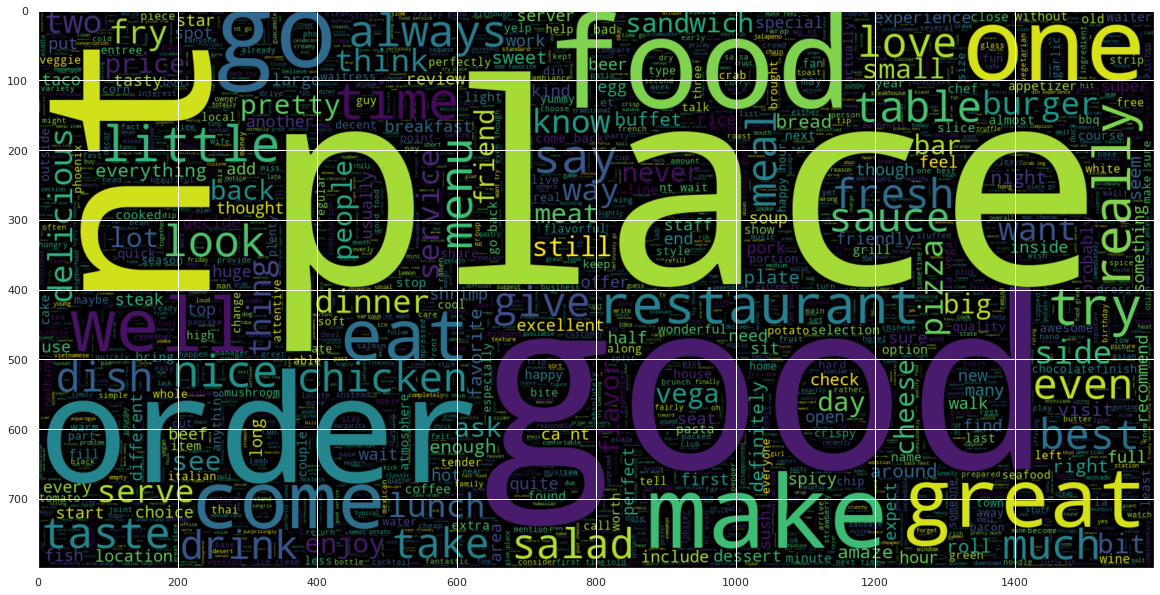

In [175]:
plt.figure(figsize = (20,20))
wc = WordCloud(min_font_size = 3,  max_words = 3000 , width = 1600 , height = 800 , stopwords = STOPWORDS, collocations=True).generate(test)
plt.imshow(wc,interpolation = 'bilinear')

## With Rake-NLTK

In [176]:
pip install rake-nltk

In [177]:
from rake_nltk import Rake
nltk.download('stopwords')
rake_nltk = Rake()
text="Feature extraction is not that complex. There are many algorithms available that can help you with feature extraction. Rapid Automatic Key Word Extraction is one of those"
rake_nltk.extract_keywords_from_text(text) # from the above concatenation
keyword_extracted = rake_nltk.get_ranked_phrases()
print(keyword_extracted)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
['rapid automatic key word extraction', 'many algorithms available', 'feature extraction', 'feature extraction', 'one', 'help', 'complex']


## With YAKE

In [178]:
pip install yake

In [179]:
import yake
kw_extractor = yake.KeywordExtractor()
text="Feature extraction is not that complex. There are many algorithms available that can help you with feature extraction. Rapid Automatic Key Word Extraction is one of those"
max_ngram_size = 3 #n-gram length
deduplication_threshold = 0.1 #avoid duplication of keywords
numOfKeywords = 10
custom_kw_extractor = yake.KeywordExtractor(lan="en", n=max_ngram_size, dedupLim=deduplication_threshold, top=numOfKeywords, features=None)
keywords = custom_kw_extractor.extract_keywords(text)
for kw in keywords:
  print(kw)

('Key Word Extraction', 0.04983902248125871)
('Automatic Key Word', 0.05810700842041131)
